In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import time
import numpy as np
import os
import pandas as pd
pd.options.display.max_columns = 100
pd.options.display.max_rows = 130

In [3]:
from utils_data import (
    load_raw_data, check_dups)

In [4]:
import pandas as pd
import numpy as np
import os
import time
import shutil
import datetime
from edge_tts import Communicate
from collections import defaultdict
from PIL import Image, ImageDraw, ImageFont
from moviepy import ImageClip, CompositeVideoClip, AudioFileClip, ColorClip, VideoFileClip
from utils_video import determine_if_text_size_too_big
from pydub import AudioSegment

In [5]:
audio_settings = {
    'voice_name_zh': 'zh-CN-XiaoxiaoNeural',
    'audio_plan': 'cparts_ce_csent',
    'pause_ms_beginning': 150,
    'pause_ms_within': 300,
    'pause_ms_between': 600,
}

# Get data

In [6]:
OUTPUT_BASE_PATH = 'output/lt_shorts/'
lt_shorts_categories = {
    '动物分类': {
        'chinese': '动物分类',
        'pinyin': 'dòngwù fēnlèi',
        'english': 'Animal Classification',
        'vocab_list': ['哺乳动物', '两栖动物', '爬行动物']
    },
    '动物分类2': {
        'chinese': '星球',
        'pinyin': 'xīng qiú',
        'english': 'planet',
        'vocab_list': ['地球', '火星', '金星', '水星', '木星', '土星', '天王星', '海王星', '冥王星']
    },
}
current_category = '动物分类'
current_category_dict = lt_shorts_categories[current_category]

current_category_dict

{'chinese': '动物分类',
 'pinyin': 'dòngwù fēnlèi',
 'english': 'Animal Classification',
 'vocab_list': ['哺乳动物', '两栖动物', '爬行动物']}

In [7]:
def load_data_settings(current_category_dict, OUTPUT_BASE_PATH):
    data_settings = current_category_dict.copy()
    data_settings['output_path'] = os.path.join(
        OUTPUT_BASE_PATH,
        current_category_dict['chinese'].replace(' ', '_')
    )
    data_settings['output_path_audio'] = os.path.join(
        data_settings['output_path'],
        'audio_files'
    )
    data_settings['output_path_images'] = os.path.join(
        data_settings['output_path'],
        'images'
    )
    return data_settings


def create_directories(data_settings, OUTPUT_BASE_PATH):
    if not os.path.exists(OUTPUT_BASE_PATH):
        os.mkdir(OUTPUT_BASE_PATH)
    if not os.path.exists(data_settings['output_path']):
        os.mkdir(data_settings['output_path'])
    if not os.path.exists(data_settings['output_path_audio']):
        os.mkdir(data_settings['output_path_audio'])
    if not os.path.exists(data_settings['output_path_images']):
        os.mkdir(data_settings['output_path_images'])

data_settings = load_data_settings(current_category_dict, OUTPUT_BASE_PATH)
create_directories(data_settings, OUTPUT_BASE_PATH)
data_settings

{'chinese': '动物分类',
 'pinyin': 'dòngwù fēnlèi',
 'english': 'Animal Classification',
 'vocab_list': ['哺乳动物', '两栖动物', '爬行动物'],
 'output_path': 'output/lt_shorts/动物分类',
 'output_path_audio': 'output/lt_shorts/动物分类/audio_files',
 'output_path_images': 'output/lt_shorts/动物分类/images'}

In [8]:
truly_load_data = True
if truly_load_data:
    df_all_vocab = load_raw_data()
    df_all_vocab.to_csv('static/latest_data.csv', index=False)
else:
    df_all_vocab = pd.read_csv('static/latest_data.csv')
    print('!!!!!!!! WARNING: not truly loading data !!!!!!!!')

df_dups = check_dups(df_all_vocab)
print(df_all_vocab.shape)
df_all_vocab.head(3)

(7489, 38)


,id,chinese,pinyin,english,type,priority,category1,category2,cat_v3,cat2_v3,cat3_v3,hsk_level,known,known_pinyin_prompt,known_english_prompt,quality,word1,word1_english,word2,word2_english,word3,word3_english,word4,word4_english,voice_zh,voice_en,video_notes,sentence,sentence_pinyin,sentence_english,date,source1,source2,funny,per,adu,slang,phonetic
0,1,房贷,fáng dài,mortgage,word,1.0,life,NaN,Finance & Economy,NaN,NaN,NONE,1.0,1.0,2.0,1.0,房子,house,贷款,loan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,他每个月都要还房贷,Ta měi gè yuè dōu yào huán fángdài,He has to pay his mortgage every month,2025-01-02,NaN,NaN,NaN,5.0,5.0,5.0,NaN
1,2,白天,bái tiān,daytime,word,2.0,time,NaN,Time,NaN,NaN,1,2.0,1.0,1.0,1.0,白,white,天,day,NaN,NaN,NaN,NaN,NaN,NaN,NaN,白天很热晚上比较凉快,Báitiān hěn rè wǎnshàng bǐjiào liángkuai,It is hot in the daytime and cooler at night,2025-01-02,NaN,NaN,NaN,5.0,5.0,5.0,NaN
2,3,组成,zǔ chéng,to form;make up,word,3.0,general,NaN,Language & Expression,NaN,NaN,2,5.0,5.0,5.0,3.0,组,set,成,become,NaN,NaN,NaN,NaN,NaN,NaN,NaN,水是由氢和氧组成的,Shuǐ shì yóu qīng hé yǎng zǔchéng de,Water is made up of hydrogen and oxygen,2025-01-02,NaN,NaN,NaN,5.0,5.0,5.0,NaN


In [9]:
# print(f'# duplicate vocab: {len(df_dups)}')
# df_dups

# Combine audio into one file

In [10]:
current_category

'动物分类'

In [11]:
current_category_dict

{'chinese': '动物分类',
 'pinyin': 'dòngwù fēnlèi',
 'english': 'Animal Classification',
 'vocab_list': ['哺乳动物', '两栖动物', '爬行动物']}

In [12]:
df_vocab_list = df_all_vocab[df_all_vocab['chinese'].isin(data_settings['vocab_list'])].reset_index(drop=True)
df_vocab_list

,id,chinese,pinyin,english,type,priority,category1,category2,cat_v3,cat2_v3,cat3_v3,hsk_level,known,known_pinyin_prompt,known_english_prompt,quality,word1,word1_english,word2,word2_english,word3,word3_english,word4,word4_english,voice_zh,voice_en,video_notes,sentence,sentence_pinyin,sentence_english,date,source1,source2,funny,per,adu,slang,phonetic
0,7019,爬行动物,pá xíng dòng wù,reptile,multi_word,5.0,NaN,NaN,Animals,NaN,NaN,MISSING,5.0,5.0,5.0,1.0,爬行,crawl,动物,animal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,蛇是典型的爬行动物。,shé shì diǎn xíng de pá xíng dòng wù.,snakes are typical reptiles.,2026-01-19,anomia_categories,NaN,NaN,5.0,5.0,5.0,NaN
1,7023,两栖动物,liǎng qī dòng wù,amphibian,multi_word,5.0,NaN,NaN,Animals,NaN,NaN,MISSING,5.0,5.0,5.0,1.0,两,two,栖息地,habitat,动物,animal,NaN,NaN,NaN,NaN,NaN,青蛙是常见的两栖动物。,qīng wā shì cháng jiàn de liǎng qī dòng wù.,frogs are common amphibians.,2026-01-19,anomia_categories,NaN,NaN,5.0,5.0,5.0,NaN
2,7027,哺乳动物,bǔ rǔ dòng wù,mammal,multi_word,5.0,NaN,NaN,Animals,NaN,NaN,MISSING,5.0,5.0,5.0,1.0,哺乳,breast feeding,动物,animal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,人类是哺乳动物。,rén lèi shì bǔ rǔ dòng wù.,humans are mammals.,2026-01-19,anomia_categories,NaN,NaN,5.0,5.0,5.0,NaN


In [13]:
def stitch_audios(audio_settings, data_settings, example_words, df_vocab_list):
    dict_audio_durations = defaultdict(list)
    if audio_settings['audio_plan'] == 'ctitle_c2word':
        current_start_time = 0

        # beginning pause
        pause_beginning = AudioSegment.silent(duration=audio_settings['pause_ms_beginning'])
        combined = pause_beginning
        dict_audio_durations['audio_path'].append('pause_beginning')
        dict_audio_durations['duration'].append(audio_settings['pause_ms_beginning'] / 1000)
        dict_audio_durations['start_time'].append(current_start_time)
        current_start_time += audio_settings['pause_ms_beginning'] / 1000
        dict_audio_durations['end_time'].append(current_start_time)

        # title
        title_audio_path = f"{data_settings['output_path_audio']}/{data_settings['category']}.mp3"
        audio = AudioSegment.from_mp3(title_audio_path)
        combined += audio
        dict_audio_durations['audio_path'].append(title_audio_path)
        dict_audio_durations['duration'].append(audio.duration_seconds)
        dict_audio_durations['start_time'].append(current_start_time)
        current_start_time += audio.duration_seconds
        dict_audio_durations['end_time'].append(current_start_time)

        # words
        for _, word in enumerate(example_words):
            # inter-word pause
            pause_inter_word = AudioSegment.silent(duration=audio_settings['pause_ms_between'])
            combined += pause_inter_word
            dict_audio_durations['audio_path'].append('inter_word_pause')
            dict_audio_durations['duration'].append(audio_settings['pause_ms_between'] / 1000)
            dict_audio_durations['start_time'].append(current_start_time)
            current_start_time += audio_settings['pause_ms_between'] / 1000
            dict_audio_durations['end_time'].append(current_start_time)
            
            # word audio
            word_audio_path = f"{data_settings['output_path_audio']}/{word}.mp3"
            audio = AudioSegment.from_mp3(word_audio_path)
            combined += audio 
            dict_audio_durations['audio_path'].append(word_audio_path)
            dict_audio_durations['duration'].append(audio.duration_seconds)
            dict_audio_durations['start_time'].append(current_start_time)
            current_start_time += audio.duration_seconds
            dict_audio_durations['end_time'].append(current_start_time)

            # within-word pause
            pause_within_word = AudioSegment.silent(duration=audio_settings['pause_ms_within_word'])
            combined += pause_within_word
            dict_audio_durations['audio_path'].append('within_word_pause')
            dict_audio_durations['duration'].append(audio_settings['pause_ms_within_word'] / 1000)
            dict_audio_durations['start_time'].append(current_start_time)
            current_start_time += audio_settings['pause_ms_within_word'] / 1000
            dict_audio_durations['end_time'].append(current_start_time)

            # word again audio
            combined += audio 
            dict_audio_durations['audio_path'].append(word_audio_path)
            dict_audio_durations['duration'].append(audio.duration_seconds)
            dict_audio_durations['start_time'].append(current_start_time)
            current_start_time += audio.duration_seconds
            dict_audio_durations['end_time'].append(current_start_time)
    
    elif audio_settings['audio_plan'] == 'cparts_ce_csent':

        def add_new_audio(combined, audio_segment, audio_name, current_start_time):
            combined += audio_segment
            dict_audio_durations['audio_name'].append(audio_name)
            dict_audio_durations['duration'].append(audio_segment.duration_seconds)
            dict_audio_durations['start_time'].append(current_start_time)
            current_start_time += audio_segment.duration_seconds
            dict_audio_durations['end_time'].append(current_start_time)
            return combined, current_start_time
        

        current_start_time = 0
        combined = AudioSegment.silent(duration=1)  # start with 1ms silence to avoid empty audio error

        # beginning pause
        combined, current_start_time = add_new_audio(
            combined, AudioSegment.silent(duration=audio_settings['pause_ms_beginning']), 'pause_beginning', current_start_time)

        # title
        title_audio_path = f"{data_settings['output_path_audio']}/{data_settings['chinese']}.mp3"
        combined, current_start_time = add_new_audio(combined, AudioSegment.from_mp3(title_audio_path), data_settings['chinese'], current_start_time)

        # words
        for current_vocab_idx, current_vocab in df_vocab_list.iterrows():
            # inter-word pause
            combined, current_start_time = add_new_audio(
                combined, AudioSegment.silent(duration=audio_settings['pause_ms_between']), 'inter_word_pause', current_start_time)
            
            # components
            for component_id in ['word1', 'word2', 'word3', 'word4']:
                if not pd.isna(current_vocab[component_id]):
                    component_audio_path = f"{data_settings['output_path_audio']}/{current_vocab[component_id]}.mp3"
                    combined, current_start_time = add_new_audio(
                        combined, AudioSegment.from_mp3(component_audio_path), f'vocab_word_{current_vocab_idx}_{component_id}', current_start_time)
                    
                    # within-word pause
                    combined, current_start_time = add_new_audio(
                        combined, AudioSegment.silent(duration=audio_settings['pause_ms_within']), 'within_word_pause', current_start_time)
            
            # vocab word chinese
            combined, current_start_time = add_new_audio(
                combined, AudioSegment.from_mp3(f"{data_settings['output_path_audio']}/{current_vocab['chinese']}.mp3"), f'vocab_word_{current_vocab_idx}_chinese', current_start_time)
            
            # within-word pause
            combined, current_start_time = add_new_audio(
                combined, AudioSegment.silent(duration=audio_settings['pause_ms_within']), 'within_word_pause', current_start_time)
            
            # vocab word english
            combined, current_start_time = add_new_audio(
                combined, AudioSegment.from_mp3(f"{data_settings['output_path_audio']}/{current_vocab['english']}.mp3"), f'vocab_word_{current_vocab_idx}_english', current_start_time)

            # within-word pause
            combined, current_start_time = add_new_audio(
                combined, AudioSegment.silent(duration=audio_settings['pause_ms_within']), 'within_word_pause', current_start_time)
            
            # sentence
            combined, current_start_time = add_new_audio(
                combined, AudioSegment.from_mp3(f"{data_settings['output_path_audio']}/{current_vocab['sentence']}.mp3"), f'vocab_word_{current_vocab_idx}_sentence', current_start_time)

    # export the combined audio file
    combined.export(f"{data_settings['output_path_audio']}/!combined.mp3", format="mp3")
    print(f'Audio duration: {combined.duration_seconds:.1f}s')

    # Add in static slide audio into dataframe of audio durations
    df_durations = pd.DataFrame(dict_audio_durations)
    return df_durations

df_durations = stitch_audios(audio_settings, data_settings, None, df_vocab_list)
df_durations.head(40)

Audio duration: 31.3s


,audio_name,duration,start_time,end_time
0,pause_beginning,0.149932,0.000000,0.149932
1,动物分类,1.536000,0.149932,1.685932
2,inter_word_pause,0.600000,1.685932,2.285932
3,vocab_word_0_word1,1.296000,2.285932,3.581932
4,within_word_pause,0.299955,3.581932,3.881887
5,vocab_word_0_word2,1.176000,3.881887,5.057887
6,within_word_pause,0.299955,5.057887,5.357841
7,vocab_word_0_chinese,1.608000,5.357841,6.965841
8,within_word_pause,0.299955,6.965841,7.265796
9,vocab_word_0_english,1.032000,7.265796,8.297796


# Create images

In [14]:
def load_video_configs():
    BG_SIZE = (720, 1280)
    video_configs = {
        'bg_size': BG_SIZE,
        'bg_color': 'white',
        'text_color': 'black',

        'max_line_length': BG_SIZE[0] - 160,
        'decrease_font_step_size': 1,
        'font_path': '/System/Library/Fonts/STHeiti Medium.ttc',

        'highlight_rect_x_buffer': 24,
        'highlight_rect_y_buffer': 10,
        'highlight_rect_color': [0, 255, 0],
        'highlight_rect_opacity': 0.5,

        'title_settings': {
            'x': 50,
            'y': 40,
            'spacing': 8,
            'align': 'center',
            'font_size': {'chinese': 48, 'pinyin': 32, 'english': 32},
            'fill': {'chinese': '#000000', 'pinyin': '#222222', 'english': '#222222'},
        },

        'words_settings': {
            'x': 50,
            'y_gap': 30,
            'between_words_spacing': 30,
            'component_words_to_vocab_word_spacing': 16,
            'vocab_word_to_sentence_spacing': 20,
            'font_size': {'components': 32, 'vocab_word': 32, 'sentence': 32},
            'spacing': {'components': 5, 'sentence': 10},
            'fill': {'components': '#555555', 'vocab_word': '#000000', 'sentence': '#000000'},
        },

        'horizontal_line': {
            'y_gap': 20,
            'x': 10,
            'color': "#1E90FF",
            'width': 10,
        },

        'bottom_line': {
            'y_gap': 10,
            'x': 10,
            'color': "#1E90FF",
            'width': 10,
        },

        'logo': {
            'font_name': 'Arial Black',
            'font_size': 20,
            'x': BG_SIZE[0] - 50,
            'y': 1110,
            'color1': "#3E78D6",
            'color2': "#2FDDFC",
        },

        'category_index': {
            'index_value': 1,
            'index_total': 100,
            'font_name': 'Arial Black',
            'font_size': 48,
            'x': 200,
            'y': 1110,
            'color1': "#000000",
            'color2': "#777777",
        },
    }
    video_configs['horizontal_line']['y'] = video_configs['title_settings']['y'] + \
        video_configs['title_settings']['font_size']['chinese']+ \
        video_configs['title_settings']['font_size']['pinyin'] + \
        video_configs['title_settings']['font_size']['english'] + \
        video_configs['horizontal_line']['y_gap'] + \
        2*video_configs['title_settings']['spacing']

    video_configs['bottom_line']['y'] = video_configs['category_index']['y'] - \
        video_configs['bottom_line']['y_gap']

    video_configs['words_settings']['y'] = video_configs['horizontal_line']['y'] + \
        video_configs['words_settings']['y_gap']
    return video_configs

video_configs = load_video_configs()
video_configs

{'bg_size': (720, 1280),
 'bg_color': 'white',
 'text_color': 'black',
 'max_line_length': 560,
 'decrease_font_step_size': 1,
 'font_path': '/System/Library/Fonts/STHeiti Medium.ttc',
 'highlight_rect_x_buffer': 24,
 'highlight_rect_y_buffer': 10,
 'highlight_rect_color': [0, 255, 0],
 'highlight_rect_opacity': 0.5,
 'title_settings': {'x': 50,
  'y': 40,
  'spacing': 8,
  'align': 'center',
  'font_size': {'chinese': 48, 'pinyin': 32, 'english': 32},
  'fill': {'chinese': '#000000', 'pinyin': '#222222', 'english': '#222222'}},
 'words_settings': {'x': 50,
  'y_gap': 30,
  'between_words_spacing': 30,
  'component_words_to_vocab_word_spacing': 16,
  'vocab_word_to_sentence_spacing': 20,
  'font_size': {'components': 32, 'vocab_word': 32, 'sentence': 32},
  'spacing': {'components': 5, 'sentence': 10},
  'fill': {'components': '#555555',
   'vocab_word': '#000000',
   'sentence': '#000000'},
  'y': 218},
 'horizontal_line': {'y_gap': 20,
  'x': 10,
  'color': '#1E90FF',
  'width': 10,



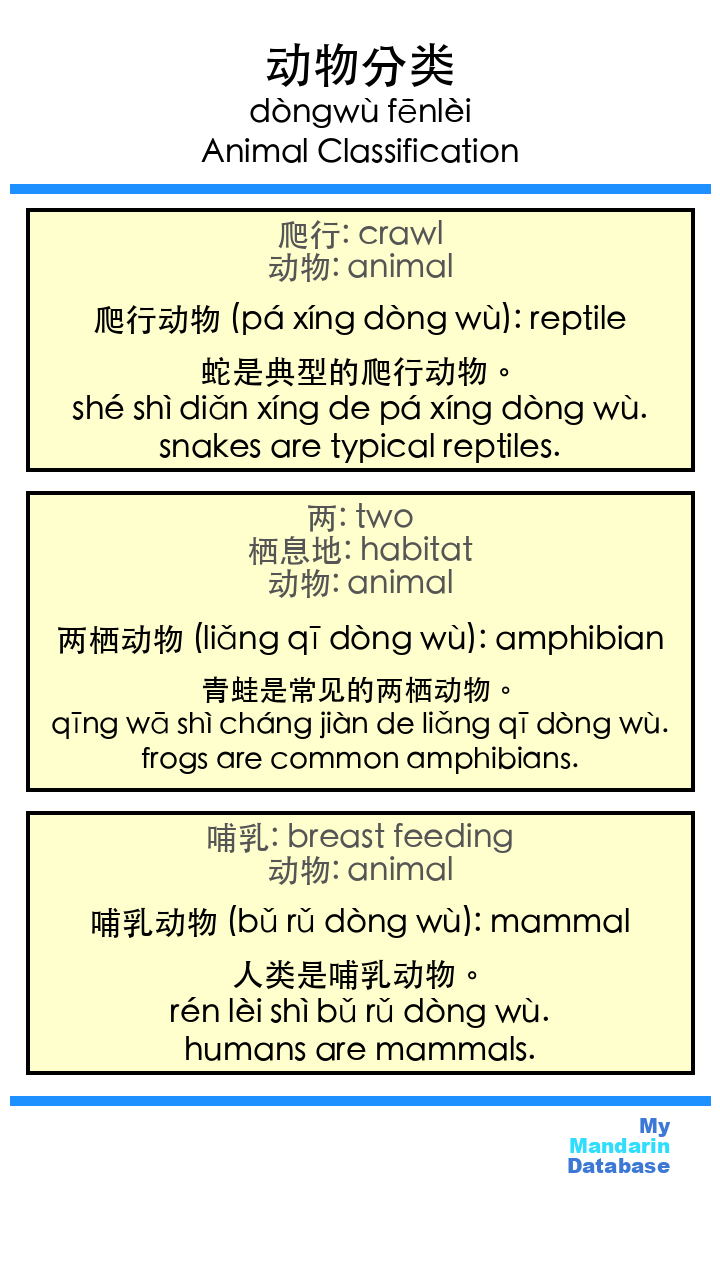

In [16]:
from utils_shorts import draw_logo, draw_resized_text_on_image

def draw_lt_vocab_list_whole_image(video_configs, data_settings, df_vocab_list):
    original_img = Image.new("RGB", video_configs['bg_size'], color=(255, 255, 255))
    draw = ImageDraw.Draw(original_img, 'RGBA')
    draw_logo(draw, video_configs)

    title_text_settings = {}
    title_text_settings['chinese'] = {
        'text': data_settings['chinese'],
        'font_path': video_configs['font_path'],
        'font_size': video_configs['title_settings']['font_size']['chinese'],
        'y': video_configs['title_settings']['y'],
        'spacing': video_configs['title_settings']['spacing'],
        'align': video_configs['title_settings']['align'],
        'fill': video_configs['title_settings']['fill']['chinese'],
        'max_line_length': video_configs['max_line_length'],
    }
    title_text_settings['pinyin'] = {
        'text': data_settings['pinyin'],
        'font_path': video_configs['font_path'],
        'font_size': video_configs['title_settings']['font_size']['pinyin'],
        'y': video_configs['title_settings']['y'] + video_configs['title_settings']['font_size']['chinese'] + video_configs['title_settings']['spacing'],
        'spacing': video_configs['title_settings']['spacing'],
        'align': video_configs['title_settings']['align'],
        'fill': video_configs['title_settings']['fill']['chinese'],
        'max_line_length': video_configs['max_line_length'],
    }
    title_text_settings['english'] = {
        'text': data_settings['english'],
        'font_path': video_configs['font_path'],
        'font_size': video_configs['title_settings']['font_size']['english'],
        'y': video_configs['title_settings']['y'] + video_configs['title_settings']['font_size']['chinese'] + video_configs['title_settings']['font_size']['pinyin'] + 2*video_configs['title_settings']['spacing'],
        'spacing': video_configs['title_settings']['spacing'],
        'align': video_configs['title_settings']['align'],
        'fill': video_configs['title_settings']['fill']['chinese'],
        'max_line_length': video_configs['max_line_length'],
    }
    draw_resized_text_on_image(draw, title_text_settings['chinese'], video_configs, is_centered=True)
    draw_resized_text_on_image(draw, title_text_settings['pinyin'], video_configs, is_centered=True)
    draw_resized_text_on_image(draw, title_text_settings['english'], video_configs, is_centered=True)


    # 4. Horizontal line
    draw.line([
        (video_configs['horizontal_line']['x'], video_configs['horizontal_line']['y']),
        (video_configs['bg_size'][0] - video_configs['horizontal_line']['x'], video_configs['horizontal_line']['y'])],
        fill=video_configs['horizontal_line']['color'],
        width=video_configs['horizontal_line']['width'],
        joint=None)
    draw.line([
        (video_configs['bottom_line']['x'], video_configs['bottom_line']['y']),
        (video_configs['bg_size'][0] - video_configs['bottom_line']['x'], video_configs['bottom_line']['y'])],
        fill=video_configs['bottom_line']['color'],
        width=video_configs['bottom_line']['width'],
        joint=None)
    
    original_img.save(f"{data_settings['output_path_images']}/title_only.png")

    # 5. Words
    for i_row, row in df_vocab_list.iterrows():            
        # Components
        if not pd.isna(row['word4']):
            n_components = 4
        elif not pd.isna(row['word3']):
            n_components = 3
        else:
            n_components = 2

        components_text = '\n'.join([f"{row[component_id]}: {row[f'{component_id}_english']}" for component_id in ['word1', 'word2', 'word3', 'word4'] if not pd.isna(row[component_id])])
        if i_row == 0:
            components_y = video_configs['words_settings']['y']
        else:
            components_y = sentence_y + (3 * video_configs['words_settings']['font_size']['sentence']) + (2 * video_configs['words_settings']['spacing']['sentence']) + video_configs['words_settings']['between_words_spacing']

        # Create binding rectangle highlight
        rect_width = video_configs['bg_size'][0] - 2*video_configs['words_settings']['x'] + 2*video_configs['highlight_rect_x_buffer']
        rect_height = (
            video_configs['highlight_rect_y_buffer'] + 
            ((3 * video_configs['words_settings']['font_size']['sentence']) + (2 * video_configs['words_settings']['spacing']['sentence'])) +
            (video_configs['words_settings']['vocab_word_to_sentence_spacing'] + video_configs['words_settings']['font_size']['vocab_word']) +
            (n_components * (video_configs['words_settings']['spacing']['components'] + video_configs['words_settings']['font_size']['components'])) + video_configs['words_settings']['component_words_to_vocab_word_spacing'] - video_configs['words_settings']['spacing']['components']
        )
        rect_x = video_configs['words_settings']['x'] - video_configs['highlight_rect_x_buffer']
        rect_y = components_y - video_configs['highlight_rect_y_buffer']

        draw.rectangle(
            [rect_x, rect_y, rect_x + rect_width, rect_y + rect_height],
            outline="#000000",
            fill=(255, 255, 0, 50),
            width=4
        )

        text_settings = {
            'text': components_text,
            'font_path': video_configs['font_path'],
            'font_size': video_configs['words_settings']['font_size']['components'],
            'x': None,
            'y': components_y,
            'spacing': video_configs['words_settings']['spacing']['components'],
            'align': 'center',
            'fill': video_configs['words_settings']['fill']['components'],
            'max_line_length': 1000,
        }
        draw_resized_text_on_image(draw, text_settings, video_configs, is_centered=True)
        original_img.save(f"{data_settings['output_path_images']}/vocab_word_{i_row}_component_only.png")
        
        # Vocab word
        vocab_word_text = f"{row['chinese']} ({row['pinyin']}): {row['english']}"
        non_components_y = components_y + (n_components * (video_configs['words_settings']['spacing']['components'] + video_configs['words_settings']['font_size']['components'])) + video_configs['words_settings']['component_words_to_vocab_word_spacing'] - video_configs['words_settings']['spacing']['components']
        text_settings = {
            'text': vocab_word_text,
            'font_path': video_configs['font_path'],
            'font_size': video_configs['words_settings']['font_size']['vocab_word'],
            'x': None,
            'y': non_components_y,
            'spacing': 0,
            'align': 'center',
            'fill': video_configs['words_settings']['fill']['vocab_word'],
            'max_line_length': 1000,
        }
        draw_resized_text_on_image(draw, text_settings, video_configs, is_centered=True)
        original_img.save(f"{data_settings['output_path_images']}/vocab_word_{i_row}_full.png")
        
        # Sentence
        vocab_word_text = f"{row['sentence']}\n{row['sentence_pinyin']}\n{row['sentence_english']}"
        font = ImageFont.truetype(video_configs['font_path'], video_configs['words_settings']['font_size']['vocab_word'])
        vocab_text_length = font.getlength(vocab_word_text)
        sentence_y = non_components_y + video_configs['words_settings']['vocab_word_to_sentence_spacing'] + video_configs['words_settings']['font_size']['vocab_word']
        text_settings = {
            'text': vocab_word_text,
            'font_path': video_configs['font_path'],
            'font_size': video_configs['words_settings']['font_size']['sentence'],
            'x': None,
            'y': sentence_y,
            'spacing': video_configs['words_settings']['spacing']['sentence'],
            'align': 'center',
            'fill': video_configs['words_settings']['fill']['sentence'],
            'max_line_length': video_configs['bg_size'][0] - 100,
        }
        draw_resized_text_on_image(draw, text_settings, video_configs, is_centered=True)
        original_img.save(f"{data_settings['output_path_images']}/vocab_word_{i_row}_sentence.png")
    return f"{data_settings['output_path_images']}/vocab_word_{i_row}_sentence.png"

no_hl_img_file_path = draw_lt_vocab_list_whole_image(video_configs, data_settings, df_vocab_list)

img_show = ImageClip(no_hl_img_file_path, duration=1).with_start(0)
img_show.display_in_notebook()

# Create video from images

In [17]:
# Computer starts and durations of each slide
tup_starts_ends = [(
    'title_only', 0, df_durations[df_durations['audio_name'] == 'inter_word_pause']['end_time'].values[0]
)]
for current_vocab_idx, current_vocab in df_vocab_list.iterrows():
    current_vocab_word_chinese_durations = df_durations[df_durations['audio_name'] == f'vocab_word_{current_vocab_idx}_chinese'].reset_index(drop=True).loc[0]
    current_vocab_word_sentence_durations = df_durations[df_durations['audio_name'] == f'vocab_word_{current_vocab_idx}_sentence'].reset_index(drop=True).loc[0]
    # components
    tup_starts_ends.append(
        (f'vocab_word_{current_vocab_idx}_component_only',
        tup_starts_ends[-1][2],
        current_vocab_word_chinese_durations['start_time'])
    )
    # full vocab word
    tup_starts_ends.append(
        (f'vocab_word_{current_vocab_idx}_full',
        tup_starts_ends[-1][2],
        current_vocab_word_sentence_durations['start_time'])
    )
    # add_sentence
    tup_starts_ends.append(
        (f'vocab_word_{current_vocab_idx}_sentence',
        tup_starts_ends[-1][2],
        current_vocab_word_sentence_durations['end_time'])
    )
    
tup_starts_ends

[('title_only', 0, np.float64(2.2859319727891156)),
 ('vocab_word_0_component_only',
  np.float64(2.2859319727891156),
  np.float64(5.35784126984127)),
 ('vocab_word_0_full',
  np.float64(5.35784126984127),
  np.float64(8.597750566893424)),
 ('vocab_word_0_sentence',
  np.float64(8.597750566893424),
  np.float64(11.213750566893424)),
 ('vocab_word_1_component_only',
  np.float64(11.213750566893424),
  np.float64(16.361614512471654)),
 ('vocab_word_1_full',
  np.float64(16.361614512471654),
  np.float64(19.64952380952381)),
 ('vocab_word_1_sentence',
  np.float64(19.64952380952381),
  np.float64(22.43352380952381)),
 ('vocab_word_2_component_only',
  np.float64(22.43352380952381),
  np.float64(26.033433106575966)),
 ('vocab_word_2_full',
  np.float64(26.033433106575966),
  np.float64(29.153342403628127)),
 ('vocab_word_2_sentence',
  np.float64(29.153342403628127),
  np.float64(31.313342403628127))]

In [18]:
# start with title only
# after inter-word-pause, go to next vocab_word_x_component_only
# after see a vocab word, go to vocab_word_x_full
df_durations

,audio_name,duration,start_time,end_time
0,pause_beginning,0.149932,0.000000,0.149932
1,动物分类,1.536000,0.149932,1.685932
2,inter_word_pause,0.600000,1.685932,2.285932
3,vocab_word_0_word1,1.296000,2.285932,3.581932
4,within_word_pause,0.299955,3.581932,3.881887
5,vocab_word_0_word2,1.176000,3.881887,5.057887
6,within_word_pause,0.299955,5.057887,5.357841
7,vocab_word_0_chinese,1.608000,5.357841,6.965841
8,within_word_pause,0.299955,6.965841,7.265796
9,vocab_word_0_english,1.032000,7.265796,8.297796


In [19]:
data_settings

{'chinese': '动物分类',
 'pinyin': 'dòngwù fēnlèi',
 'english': 'Animal Classification',
 'vocab_list': ['哺乳动物', '两栖动物', '爬行动物'],
 'output_path': 'output/lt_shorts/动物分类',
 'output_path_audio': 'output/lt_shorts/动物分类/audio_files',
 'output_path_images': 'output/lt_shorts/动物分类/images'}

In [20]:
video_configs

{'bg_size': (720, 1280),
 'bg_color': 'white',
 'text_color': 'black',
 'max_line_length': 560,
 'decrease_font_step_size': 1,
 'font_path': '/System/Library/Fonts/STHeiti Medium.ttc',
 'highlight_rect_x_buffer': 24,
 'highlight_rect_y_buffer': 10,
 'highlight_rect_color': [0, 255, 0],
 'highlight_rect_opacity': 0.5,
 'title_settings': {'x': 50,
  'y': 40,
  'spacing': 8,
  'align': 'center',
  'font_size': {'chinese': 48, 'pinyin': 32, 'english': 32},
  'fill': {'chinese': '#000000', 'pinyin': '#222222', 'english': '#222222'}},
 'words_settings': {'x': 50,
  'y_gap': 30,
  'between_words_spacing': 30,
  'component_words_to_vocab_word_spacing': 16,
  'vocab_word_to_sentence_spacing': 20,
  'font_size': {'components': 32, 'vocab_word': 32, 'sentence': 32},
  'spacing': {'components': 5, 'sentence': 10},
  'fill': {'components': '#555555',
   'vocab_word': '#000000',
   'sentence': '#000000'},
  'y': 218},
 'horizontal_line': {'y_gap': 20,
  'x': 10,
  'color': '#1E90FF',
  'width': 10,


In [21]:
tup_starts_ends

[('title_only', 0, np.float64(2.2859319727891156)),
 ('vocab_word_0_component_only',
  np.float64(2.2859319727891156),
  np.float64(5.35784126984127)),
 ('vocab_word_0_full',
  np.float64(5.35784126984127),
  np.float64(8.597750566893424)),
 ('vocab_word_0_sentence',
  np.float64(8.597750566893424),
  np.float64(11.213750566893424)),
 ('vocab_word_1_component_only',
  np.float64(11.213750566893424),
  np.float64(16.361614512471654)),
 ('vocab_word_1_full',
  np.float64(16.361614512471654),
  np.float64(19.64952380952381)),
 ('vocab_word_1_sentence',
  np.float64(19.64952380952381),
  np.float64(22.43352380952381)),
 ('vocab_word_2_component_only',
  np.float64(22.43352380952381),
  np.float64(26.033433106575966)),
 ('vocab_word_2_full',
  np.float64(26.033433106575966),
  np.float64(29.153342403628127)),
 ('vocab_word_2_sentence',
  np.float64(29.153342403628127),
  np.float64(31.313342403628127))]

In [22]:
data_settings

{'chinese': '动物分类',
 'pinyin': 'dòngwù fēnlèi',
 'english': 'Animal Classification',
 'vocab_list': ['哺乳动物', '两栖动物', '爬行动物'],
 'output_path': 'output/lt_shorts/动物分类',
 'output_path_audio': 'output/lt_shorts/动物分类/audio_files',
 'output_path_images': 'output/lt_shorts/动物分类/images'}

In [23]:
def create_video_with_concat_images(tup_starts_ends, data_settings):
    # For each clip, get the image
    clips = []
    for clip_name, start_time, end_time in tup_starts_ends:
        img_file_path = f"{data_settings['output_path_images']}/{clip_name}.png"
        duration = end_time - start_time
        print(f'Adding clip: {img_file_path} for duration {duration:.1f}s')
        clips.append(ImageClip(img_file_path, duration=duration).with_start(start_time))

    audio_for_video = AudioFileClip(f"{data_settings['output_path_audio']}/!combined.mp3")
    audio_duration = audio_for_video.duration
    print(f'Final audio duration: {audio_duration:.3f}s')
    final_video = CompositeVideoClip(clips)
    print(f'Final video duration before audio set: {final_video.duration:.3f}s')
    final_video.audio = audio_for_video
    final_video.write_videofile(f"{data_settings['output_path']}/{data_settings['chinese']}_video.mp4", fps=24)


    # combined_audio = AudioFileClip(f"{data_settings['output_path_audio']}/combined.mp3")
    # clips_no_highlights = [ImageClip(no_hl_img_file_path, duration=combined_audio.duration).with_start(0)]
    # video = CompositeVideoClip(clips_no_highlights, size=video_configs['bg_size'])
    # video.audio = combined_audio
    # video.duration = combined_audio.duration
    # no_highlights_video_path = f"{data_settings['output_path']}/{data_settings['category']}_no_highlights.mp4"
    # video.write_videofile(no_highlights_video_path, fps=24)

create_video_with_concat_images(tup_starts_ends, data_settings)

Adding clip: output/lt_shorts/动物分类/images/title_only.png for duration 2.3s
Adding clip: output/lt_shorts/动物分类/images/vocab_word_0_component_only.png for duration 3.1s
Adding clip: output/lt_shorts/动物分类/images/vocab_word_0_full.png for duration 3.2s
Adding clip: output/lt_shorts/动物分类/images/vocab_word_0_sentence.png for duration 2.6s
Adding clip: output/lt_shorts/动物分类/images/vocab_word_1_component_only.png for duration 5.1s
Adding clip: output/lt_shorts/动物分类/images/vocab_word_1_full.png for duration 3.3s
Adding clip: output/lt_shorts/动物分类/images/vocab_word_1_sentence.png for duration 2.8s
Adding clip: output/lt_shorts/动物分类/images/vocab_word_2_component_only.png for duration 3.6s
Adding clip: output/lt_shorts/动物分类/images/vocab_word_2_full.png for duration 3.1s
Adding clip: output/lt_shorts/动物分类/images/vocab_word_2_sentence.png for duration 2.2s
Final audio duration: 31.370s
Final video duration before audio set: 31.313s
MoviePy - Building video output/lt_shorts/动物分类/动物分类_video.mp4.
Movie

MoviePy - Done.
MoviePy - Writing video output/lt_shorts/动物分类/动物分类_video.mp4



MoviePy - Done !
MoviePy - video ready output/lt_shorts/动物分类/动物分类_video.mp4
